# DAY 13
# DATE - 01.06.2026
# Raster Data Processing — rasterio + GDAL

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np
import os

input_path = '/content/drive/MyDrive/MISSION_RS_SDA/Odisha_NDVI_2026.tif'

if not os.path.exists(input_path):
    print("Bhai, path galat hai! Ek baar check karo.")
else:
    # 1. READ: File open karo
    with rasterio.open(input_path) as src:
        print("--- Original Image Specs ---")
        print(f"Shape: {src.height}x{src.width} | Total Bands: {src.count} (Single Band detected!)")
        print(f"CRS: {src.crs}\n")

        meta = src.meta.copy()

        # Band 4 ki jagah direct Band 1 read karo kyunki yahi hamara NDVI hai
        ndvi_direct = src.read(1).astype('float32')

    # 2. PROCESS: Kyunki GEE se data kabhi-kabhi raw scale (0-255 ya scaling factor) me aata hai,
    # ya agar kuch pixels -1 aur 1 ke bahar hain toh unhe clip kar dete hain cleanup ke liye.
    ndvi_processed = np.clip(ndvi_direct, -1.0, 1.0)
    print("Direct NDVI extraction and cleaning successful!")

    # 3. WRITE: Nayi file me save karo
    meta.update({
        'driver': 'GTiff',
        'dtype': 'float32',
        'count': 1
    })

    output_path = '/content/drive/MyDrive/MISSION_RS_SDA/Odisha_Calculated_NDVI_Output.tif'

    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(ndvi_processed, 1)

    print(f"\nBhai, pipeline chal gayi! Nayi Single-Band GeoTIFF yahan save ho gayi:\n{output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Original Image Specs ---
Shape: 670x669 | Total Bands: 1 (Single Band detected!)
CRS: EPSG:4326

Direct NDVI extraction and cleaning successful!

Bhai, pipeline chal gayi! Nayi Single-Band GeoTIFF yahan save ho gayi:
/content/drive/MyDrive/MISSION_RS_SDA/Odisha_Calculated_NDVI_Output.tif


--- METADATA REPORT ---
CRS (Coordinate Reference System): EPSG:4326
Transform Matrix:
| 0.00, 0.00, 84.00|
| 0.00,-0.00, 22.01|
| 0.00, 0.00, 1.00|
Width (Columns): 669 pixels
Height (Rows): 670 pixels
Band Count: 1 bands



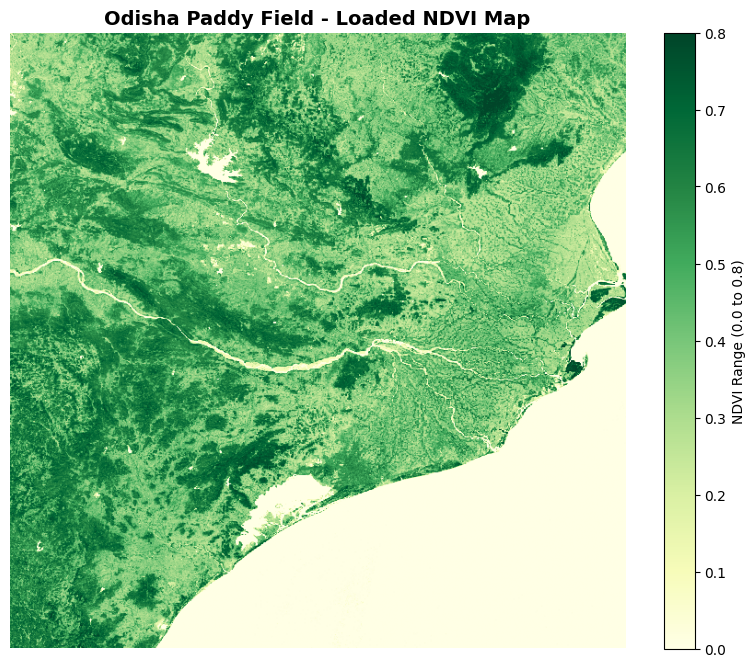

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

input_path = '/content/drive/MyDrive/MISSION_RS_SDA/Odisha_NDVI_2026.tif'

with rasterio.open(input_path) as dataset:
    print("--- METADATA REPORT ---")
    print(f"CRS (Coordinate Reference System): {dataset.crs}")
    print(f"Transform Matrix:\n{dataset.transform}")
    print(f"Width (Columns): {dataset.width} pixels")
    print(f"Height (Rows): {dataset.height} pixels")
    print(f"Band Count: {dataset.count} bands\n")

    # Band 4 aur 8 ki jagah direct Band 1 read karo (Kyunki file single band hai)
    ndvi_calc = dataset.read(1).astype('float32')

# Plotting the NDVI (Ab formula lagane ki zarurat nahi, data pehle se ready hai)
plt.figure(figsize=(10, 8))
img = plt.imshow(ndvi_calc, cmap='YlGn', vmin=0, vmax=0.8)

plt.title("Odisha Paddy Field - Loaded NDVI Map", fontsize=14, fontweight='bold')
plt.colorbar(img, label="NDVI Range (0.0 to 0.8)")
plt.axis('off')
plt.show()